Carrying colours and labels: barycentric projection
===================================================

**When to use:** the points of one cloud carry attributes (colours, classes, any feature) and you want them on the
points of another cloud, through the transport plan.

**What you will see:** the colours of a 307,200-pixel photograph moved onto a palette by OT in RGB space, and class
labels carried from 100,000 labelled points to 100,000 unlabelled ones, where an unbalanced transport leaves a
distant region unlabelled. GeomLoss shows both ideas on smaller data:
https://www.kernel-operations.io/geomloss/_auto_examples/index.html

Source: [plot_attribute_transfer.py](plot_attribute_transfer.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/advanced/plot_attribute_transfer.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/advanced/plot_attribute_transfer.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
from pathlib import Path

import matplotlib
import matplotlib.cbook as cbook
import matplotlib.image as mimage
import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import dense_size, images_dir, require_cuda, save, timed, to_numpy  # noqa: E402
from _transport import apply_plan_transpose, barycentric_targets  # noqa: E402

device = require_cuda()
torch.manual_seed(0)

Colour transfer
---------------
Every pixel is a point in RGB space. The photograph (matplotlib's sample image of Grace Hopper, a public-domain
US Navy photograph) has 307,200 pixels; the palette image is generated: matplotlib's plasma colour map on a
smooth random field. The barycentric projection moves each pixel to the average palette colour the plan sends
it to, (P y) / (P 1). As in the basics example, the plan comes from a careful solve: FP32 and ``scaling=0.95``.

In [ ]:
photo = torch.tensor(mimage.imread(cbook.get_sample_data("grace_hopper.jpg", asfileobj=False)) / 255.0,
                     dtype=torch.float32, device=device)
field = torch.nn.functional.avg_pool2d(torch.randn(1, 1, 320, 320, device=device), 65, stride=1).squeeze()
field = (field - field.min()) / (field.max() - field.min())
palette = torch.tensor(matplotlib.colormaps["plasma"](to_numpy(field))[..., :3], dtype=torch.float32, device=device)
source, target = photo.reshape(-1, 3), palette.reshape(-1, 3)
a = torch.full((len(source),), 1.0 / len(source), device=device)
b = torch.full((len(target),), 1.0 / len(target), device=device)
print(dense_size(len(source), len(target)))
blur = 0.05
colours = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                      scaling=0.95, allow_tf32=False, autotune=False)
f, g = timed("potentials, scaling=0.95, FP32", lambda: colours(a, source, b, target))
recoloured = timed("barycentric projection of every pixel",
                   lambda: barycentric_targets(source, target, f, g, a, b, eps=blur**2, cost_scale=0.5))
fig, axes = plt.subplots(1, 3, figsize=(13.0, 5.0))
for ax, image, title in zip(axes, (photo, palette, recoloured.reshape(photo.shape)),
                            ("photograph", "palette", "photograph in the palette's colours")):
    ax.imshow(to_numpy(image.clamp(0, 1)))
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
save(fig, images_dir(__file__), "colour_transfer")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/advanced/images/colour_transfer.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

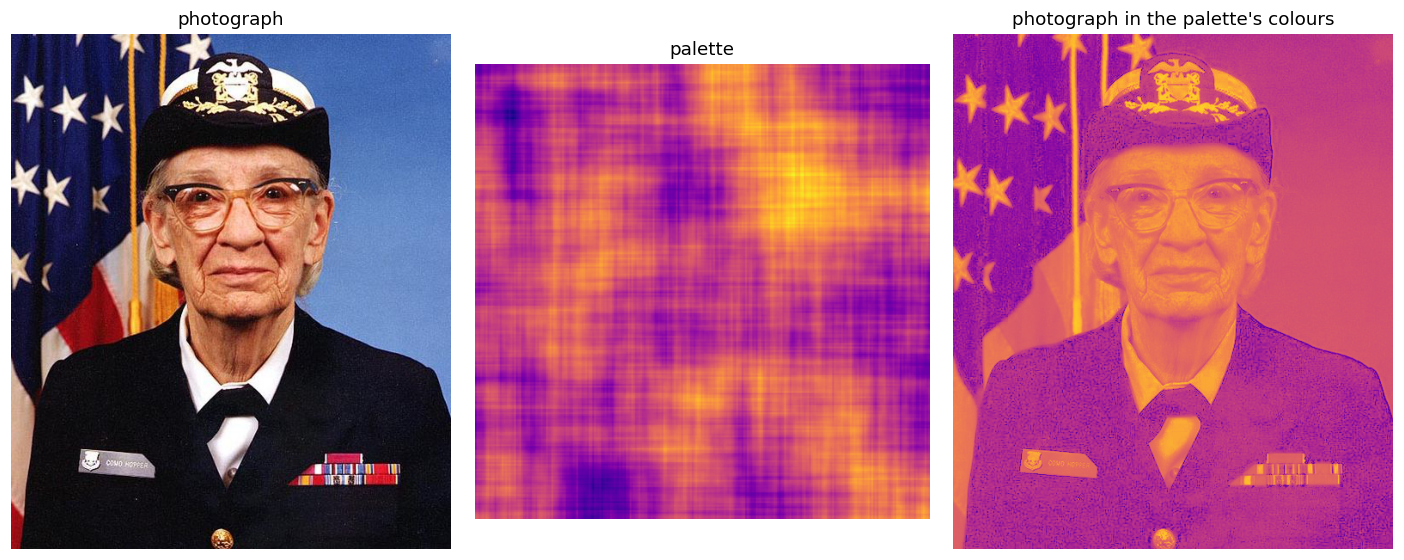

Label transfer
--------------
Source points on a ring carry three labels by sector (red, green, blue). The unlabelled target is a wider ring
plus a distant disk with 10% of the points. A target point's label is the plan-weighted average of the labels sent
to it, (P' onehot) / (P' 1). Balanced OT must send mass to the distant disk and labels it; with ``reach``, mass is
destroyed rather than carried that far, and target points that receive almost nothing stay unlabelled (black).

In [ ]:
n = 100_000
angle = 2 * math.pi * torch.rand(n, device=device)
xs = torch.stack([angle.cos(), angle.sin()], dim=1) * (1 + 0.05 * torch.randn(n, 1, device=device))
labels = (angle / (2 * math.pi / 3)).long().clamp(max=2)
far = n // 10
angle_t = 2 * math.pi * torch.rand(n - far, device=device)
ring = torch.stack([angle_t.cos(), angle_t.sin()], dim=1) * (1.2 + 0.15 * torch.randn(n - far, 1, device=device))
disk = 0.3 * torch.randn(far, 2, device=device) + torch.tensor([3.0, 3.0], device=device)
yt = torch.cat([ring, disk])
an = torch.full((n,), 1.0 / n, device=device)
onehot = torch.nn.functional.one_hot(labels, 3).float()
blur = 0.1
panels = {}
for name, relaxation in (("balanced", {}), ("reach = 1", dict(reach=1.0))):
    loss = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                       scaling=0.95, allow_tf32=False, autotune=False, **relaxation)
    f, g = loss(an, xs, an, yt)
    received = apply_plan_transpose(xs, yt, f, g, an, an, onehot, eps=blur**2, cost_scale=0.5)  # (n, 3)
    mass = received.sum(dim=1)
    soft = received / mass.clamp_min(1e-30)[:, None]
    panels[name] = soft * (mass / an).clamp(max=1.0)[:, None]  # fades to black where little mass arrives
    print(f"{name}: share of the distant disk's mass received {mass[-far:].sum().item() / an[-far:].sum().item():.3f}")
print(f"peak memory {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB on {torch.cuda.get_device_name()}")
fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.0))
xs_np, yt_np = to_numpy(xs), to_numpy(yt)
axes[0].scatter(xs_np[:, 0], xs_np[:, 1], s=0.3, c=to_numpy(onehot), edgecolors="none", rasterized=True)
axes[0].set_title("labelled source")
for ax, (name, colours_t) in zip(axes[1:], panels.items()):
    ax.scatter(yt_np[:, 0], yt_np[:, 1], s=0.3, c=to_numpy(colours_t.clamp(0, 1)), edgecolors="none",
               rasterized=True)
    ax.set_title(f"target, {name}")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-1.8, 4.2)
    ax.set_ylim(-1.8, 4.2)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
save(fig, images_dir(__file__), "label_transfer")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/advanced/images/label_transfer.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

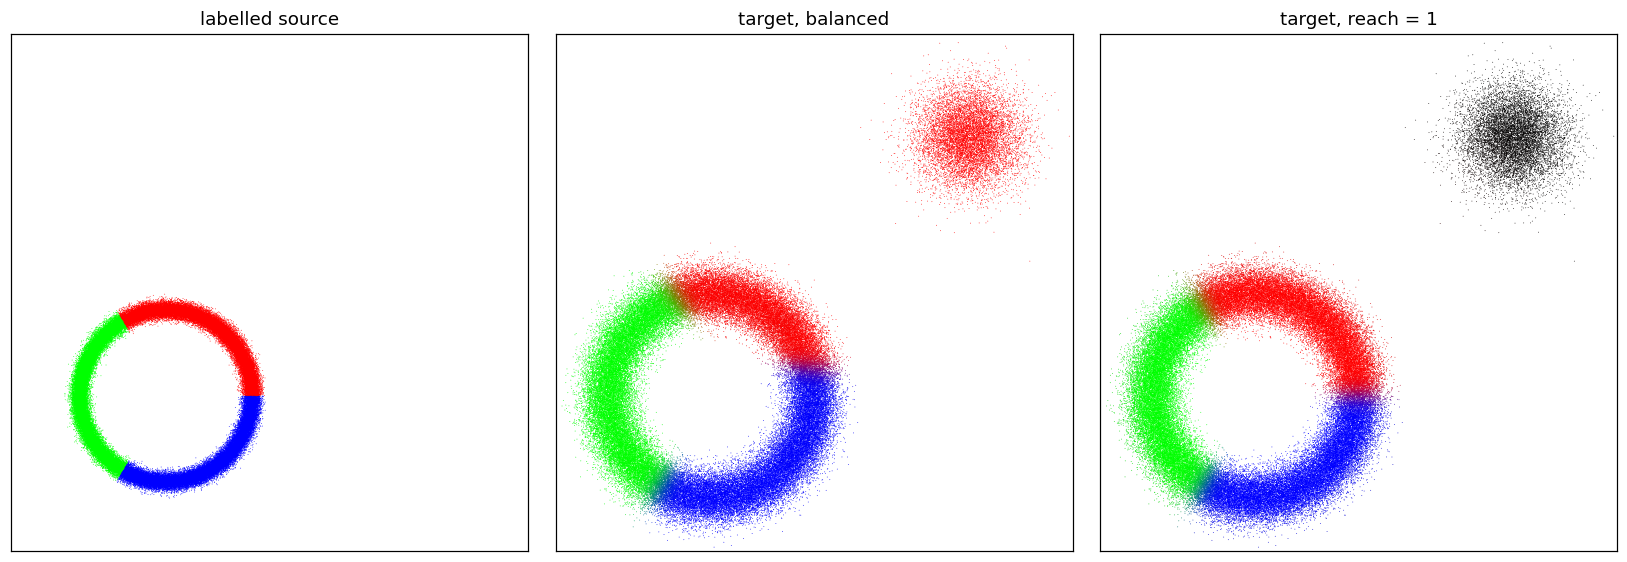